In [2]:
import os 
import pandas as pd
import phonenumbers 
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv(os.path.join('Data.csv'))

In [4]:
df.head(10)

,Name,CategoryName,Contact Number,City,Address,Website
0,Javed Iqbal Medical Store,Medical Center,NaN,Chitrāl,"Zero point Drosh, Bazar, Chitrāl,",NaN
1,Kausar First Aid & Medical Centre,Hospital,+92 333 3916780,Khuzdar,"Basima - Khuzdar Hwy, Khuzdar,",NaN
2,Rimsa Medical Center,Medical Center,NaN,Dādu,"PQHC+CMC, Police Line Rd, Dādu,",NaN
3,Government Medical Institute of science kidney...,Hospital department,+92 316 3283892,Gambat,"9G2G+394, Gambat, 66070,",NaN
4,Dr Amjad Ali,Hospital,+92 244 360307,Nawabshah,"Chowk, Mohsin Medicare Center, Masjid Rd, near...",NaN
5,Civil Hospital Larkana,Hospital,+92 335 6559909,Larkana,"H636+94G civil hospital, Jail Raod, Larkana,",NaN
6,River City Hospital Sukkur,Hospital,+92 71 5825050,Sukkur,"PRG7+6XF, Imdad Ali Awan Rd, Soarth Memon Hous...",NaN
7,"PAF Hospital, Shahbaz",Hospital,+92 330 3216095,Jacobabad,"7FHH+4V2, Jacobabad,",NaN
8,Red Crescent Hospital Sukkur,Hospital,+92 243 715743,Sukkur,"MVW8+9G4, Sanghi, 65200,",NaN
9,DHQ Hospital Kamber,Government hospital,NaN,Qambar,"HXJW+9XC, Qambar,",NaN


In [5]:
df.isnull().sum()

Name                0
CategoryName        5
Contact Number    302
City               25
Address             0
Website           610
dtype: int64

# EDA

In [6]:
df.describe()

,Name,CategoryName,Contact Number,City,Address,Website
count,693,688,391,668,693,83
unique,646,57,386,282,688,80
top,Hospital,Hospital,+92 800 777 55,Peshawar,"Gojra,",www.siut.org/
freq,18,493,4,50,3,2


**Categorical Analysis**

In [7]:
df['CategoryName'].value_counts()
df_index=df['CategoryName'].value_counts().head(10)

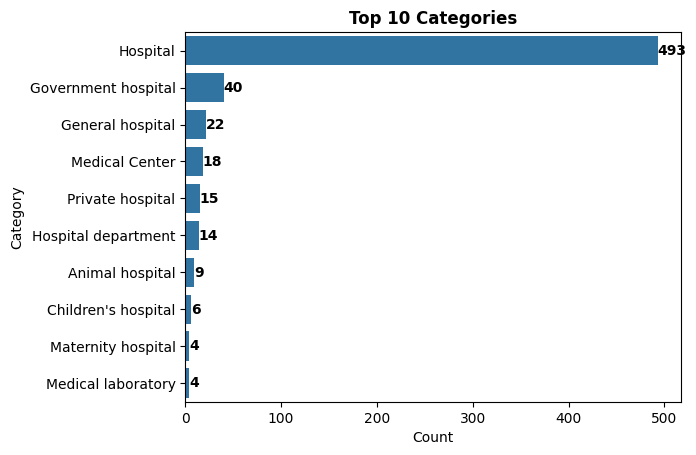

In [8]:
ax=sns.countplot(y='CategoryName', data=df, order=df_index.index)
plt.xlabel('Count')
plt.ylabel('Category')
plt.title('Top 10 Categories', fontweight='bold')
for container in ax.containers:
    ax.bar_label(container,fontweight='bold')
plt.show()

<Figure size 1000x1000 with 0 Axes>

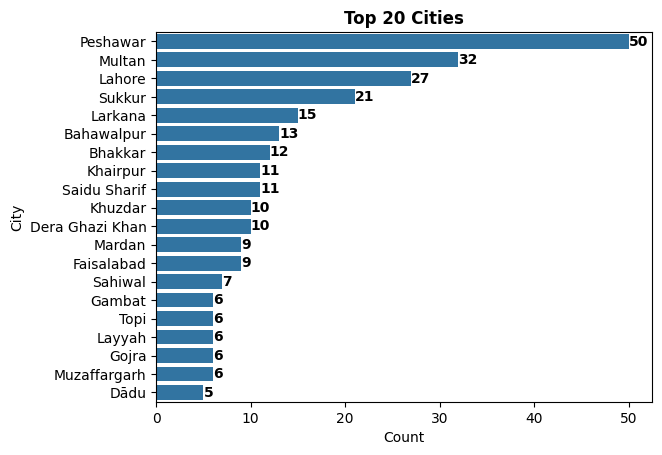

<Figure size 1000x1000 with 0 Axes>

In [9]:
df['City'].value_counts() 
city_index=df['City'].value_counts().head(20)
ax=sns.countplot(y='City',data=df,order=city_index.index)
for container in ax.containers:
    ax.bar_label(container,fontweight='bold')
plt.ylabel('City')
plt.xlabel('Count')
plt.title('Top 20 Cities', fontweight='bold')
plt.figure(figsize=(10,10))

# Numerical

In [13]:
def is_valid(phone, region=None):
    try:
        parse_phone = phonenumbers.parse(phone, region)
        return phonenumbers.is_valid_number(parse_phone)
    except phonenumbers.NumberParseException:
        return False

    

In [ ]:
is_valid_numbers = df['Contact Number'].apply(lambda x: is_valid(str(x)))
valid_count = is_valid_numbers.sum()
invalid_count = len(is_valid_numbers) - valid_count
print(f"Valid phone numbers: {valid_count}")
print(f"Invalid phone numbers: {invalid_count}")


In [ ]:
df['Contact Number'] = df['Contact Number'].str.replace(r'^\+92','0', regex=True)
num_df=df['Contact Number']=df['Contact Number'].str.replace(' ','', regex=False )
num_df

#Validation of contact numbers
for i in num_df:
    if len(i) != 11:
        print(f"Invalid contact number: {i}")

TypeError: object of type 'float' has no len()